In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

In [2]:
df = pd.read_csv("/Users/ruch/Desktop/ML-Engineer/Core/Data Science/Sleep Health and Lifestyle Prediction/Sleep_health_and_lifestyle_dataset.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [3]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [5]:
df.shape

(374, 13)

In [6]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [7]:
df.value_counts()

Person ID  Gender  Age  Occupation            Sleep Duration  Quality of Sleep  Physical Activity Level  Stress Level  BMI Category  Blood Pressure  Heart Rate  Daily Steps  Sleep Disorder
4          Male    28   Sales Representative  5.9             4                 30                       8             Obese         140/90          85          3000         Sleep Apnea       1
290        Female  50   Nurse                 6.1             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
283        Female  50   Nurse                 6.0             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
284        Female  50   Nurse                 6.0             6                 90                       8             Overweight    140/95          75          10000        Sleep Apnea       1
285        Female  50   Nurse      

In [8]:
df["Sleep Disorder"].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

In [9]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

In [10]:
219 + 78 + 77

374

In [11]:
df["Blood Pressure"]

0      126/83
1      125/80
2      125/80
3      140/90
4      140/90
        ...  
369    140/95
370    140/95
371    140/95
372    140/95
373    140/95
Name: Blood Pressure, Length: 374, dtype: object

In [12]:
df["Blood Pressure"].str.isnumeric().sum()

0

In [13]:
df[['Systolic', 'Diastolic']] = df['Blood Pressure'].str.split('/', expand=True) # expand=True Listeyi genişlet, her elemanı ayrı sütuna koy.
df['Systolic'] = df['Systolic'].astype(float)
df['Diastolic'] = df['Diastolic'].astype(float)
df = df.drop(columns=['Blood Pressure'])

In [14]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126.0,83.0
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
 12  Systolic                 374 non-null    float64
 13  Diastolic                374 non-null    float64
dtypes: float64(3), int64(7), o

In [16]:
df.drop("Person ID", inplace=True, axis=1)

In [17]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [18]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('Healthy')

In [19]:
df["Sleep Disorder"].value_counts()

Sleep Disorder
Healthy        219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64

In [20]:
numeric_features = df.select_dtypes(include=[np.number])
numeric_features

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic,Diastolic
0,27,6.1,6,42,6,77,4200,126.0,83.0
1,28,6.2,6,60,8,75,10000,125.0,80.0
2,28,6.2,6,60,8,75,10000,125.0,80.0
3,28,5.9,4,30,8,85,3000,140.0,90.0
4,28,5.9,4,30,8,85,3000,140.0,90.0
...,...,...,...,...,...,...,...,...,...
369,59,8.1,9,75,3,68,7000,140.0,95.0
370,59,8.0,9,75,3,68,7000,140.0,95.0
371,59,8.1,9,75,3,68,7000,140.0,95.0
372,59,8.1,9,75,3,68,7000,140.0,95.0


In [21]:
categorical_features = df.select_dtypes(include=[object])
categorical_features

,Gender,Occupation,BMI Category,Sleep Disorder
0,Male,Software Engineer,Overweight,Healthy
1,Male,Doctor,Normal,Healthy
2,Male,Doctor,Normal,Healthy
3,Male,Sales Representative,Obese,Sleep Apnea
4,Male,Sales Representative,Obese,Sleep Apnea
...,...,...,...,...
369,Female,Nurse,Overweight,Sleep Apnea
370,Female,Nurse,Overweight,Sleep Apnea
371,Female,Nurse,Overweight,Sleep Apnea
372,Female,Nurse,Overweight,Sleep Apnea


In [22]:
categorical_features_list = categorical_features.columns.tolist()
categorical_features_list

['Gender', 'Occupation', 'BMI Category', 'Sleep Disorder']

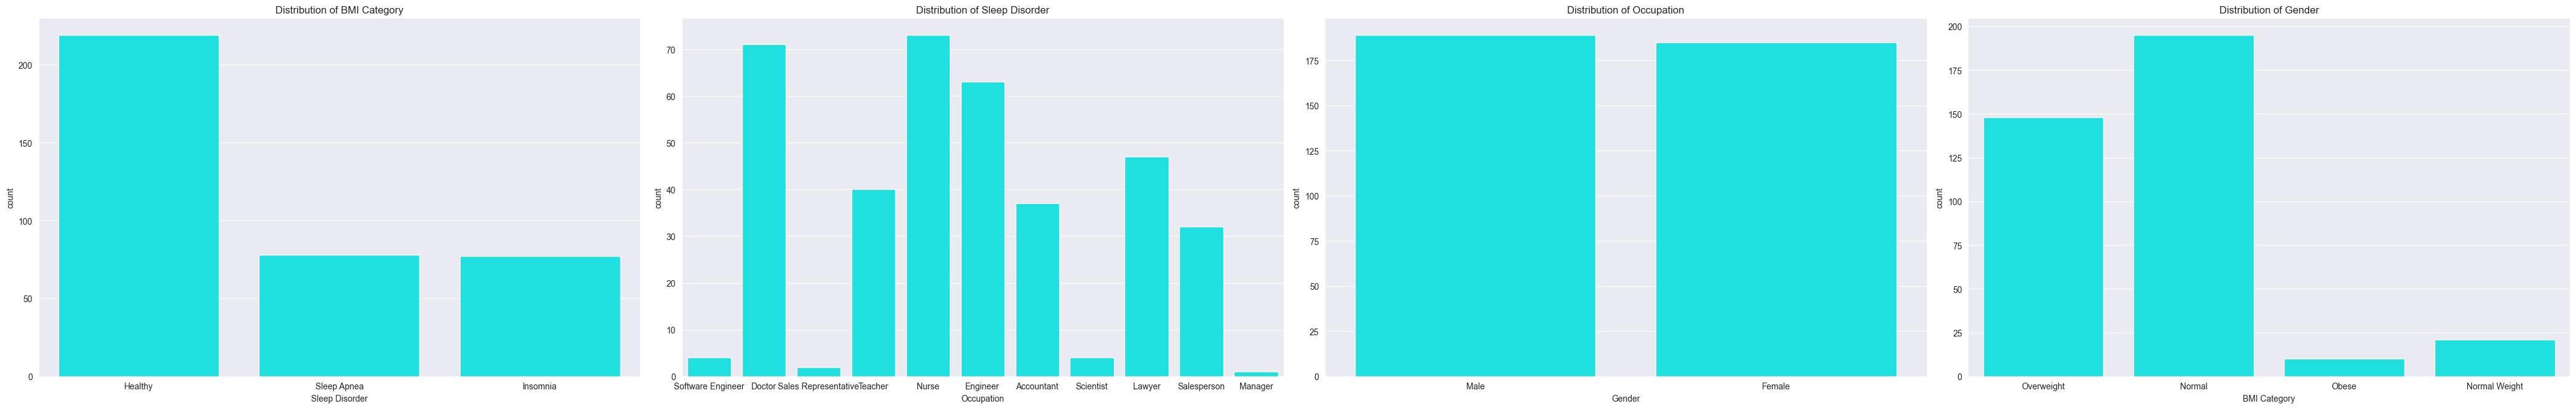

In [23]:
plt.figure(figsize=(42,32))

category = ['Sleep Disorder', 'Occupation', 'Gender', 'BMI Category']

for i in range(0, len(category)):
    plt.subplot(5, 4, i+1)
    sns.countplot(x=df[category[i]], color='cyan')
    plt.xlabel(category[i])
    plt.title(f'Distribution of {category[i-1]}')
    plt.tight_layout()

plt.show()

In [24]:
numeric_features_list = numeric_features.columns.tolist()
numeric_features_list

['Age',
 'Sleep Duration',
 'Quality of Sleep',
 'Physical Activity Level',
 'Stress Level',
 'Heart Rate',
 'Daily Steps',
 'Systolic',
 'Diastolic']

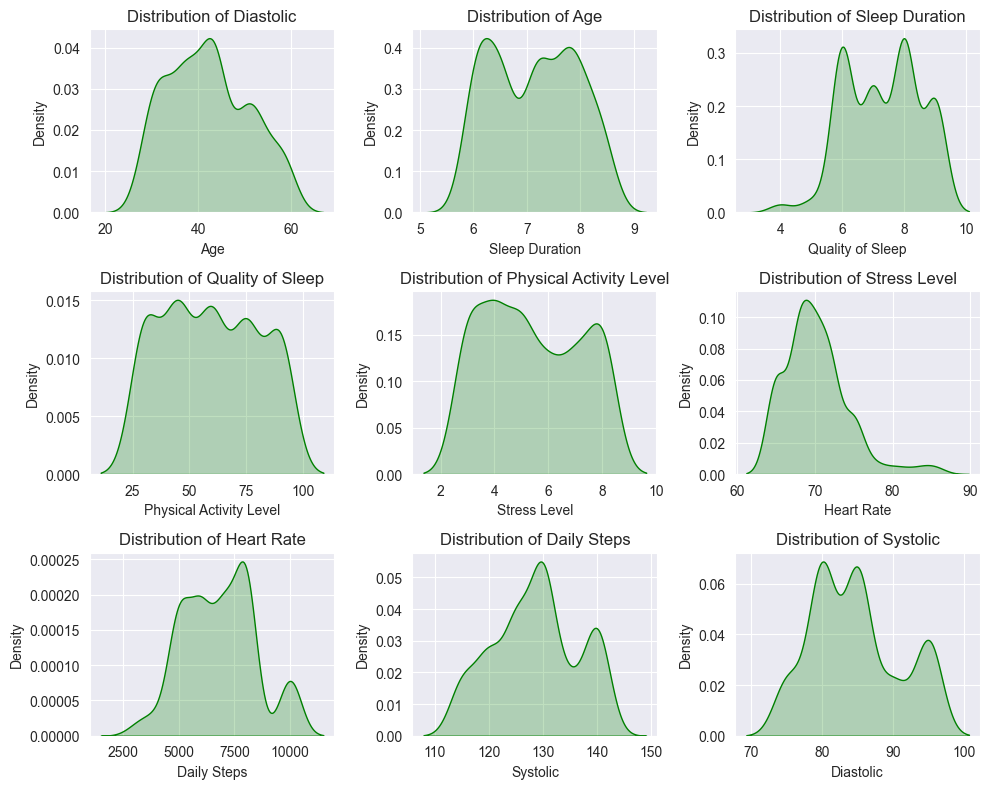

In [25]:
plt.figure(figsize=(10,8))

for i in range(0, len(numeric_features_list)):
    plt.subplot(3, 3, i+1)
    sns.kdeplot(x=df[numeric_features_list[i]], color='green', fill=True)
    plt.xlabel(numeric_features_list[i])
    plt.title(f'Distribution of {numeric_features_list[i-1]}')
    plt.tight_layout()

plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 38.1+ KB


In [27]:
df.shape

(374, 13)

In [28]:
df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,Healthy,126.0,83.0
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125.0,80.0
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,Healthy,125.0,80.0
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140.0,90.0


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    object 
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(6), object(4)
memory usage: 38.1+ KB


In [30]:
label_encoder = LabelEncoder()

In [31]:
df["Gender"]

0        Male
1        Male
2        Male
3        Male
4        Male
        ...  
369    Female
370    Female
371    Female
372    Female
373    Female
Name: Gender, Length: 374, dtype: object

In [32]:
df["Gender"] = label_encoder.fit_transform(df["Gender"])

In [33]:
df["Gender"]

0      1
1      1
2      1
3      1
4      1
      ..
369    0
370    0
371    0
372    0
373    0
Name: Gender, Length: 374, dtype: int64

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    object 
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(7), object(3)
memory usage: 38.1+ KB


In [35]:
df["Occupation"].value_counts()

Occupation
Nurse                   73
Doctor                  71
Engineer                63
Lawyer                  47
Teacher                 40
Accountant              37
Salesperson             32
Software Engineer        4
Scientist                4
Sales Representative     2
Manager                  1
Name: count, dtype: int64

In [36]:
encoder = LabelEncoder()
df['Occupation'] = encoder.fit_transform(df['Occupation'])

In [37]:
df["Occupation"]

0      9
1      1
2      1
3      6
4      6
      ..
369    5
370    5
371    5
372    5
373    5
Name: Occupation, Length: 374, dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    object 
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(8), object(2)
memory usage: 38.1+ KB


In [39]:
df["BMI Category"].unique()

array(['Overweight', 'Normal', 'Obese', 'Normal Weight'], dtype=object)

In [40]:
df["BMI Category"] = df["BMI Category"].replace("Normal", "Underweight")

In [41]:
df["BMI Category"].unique()

array(['Overweight', 'Underweight', 'Obese', 'Normal Weight'],
      dtype=object)

In [42]:
bmi_order = {
    'Underweight': 0,
    'Normal Weight': 1,
    'Overweight': 2,
    'Obese': 3
}

df['BMI Category'] = df['BMI Category'].map(bmi_order)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    int64  
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    object 
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(9), object(1)
memory usage: 38.1+ KB


In [44]:
df.tail()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
369,0,59,5,8.1,9,75,3,2,68,7000,Sleep Apnea,140.0,95.0
370,0,59,5,8.0,9,75,3,2,68,7000,Sleep Apnea,140.0,95.0
371,0,59,5,8.1,9,75,3,2,68,7000,Sleep Apnea,140.0,95.0
372,0,59,5,8.1,9,75,3,2,68,7000,Sleep Apnea,140.0,95.0
373,0,59,5,8.1,9,75,3,2,68,7000,Sleep Apnea,140.0,95.0


In [45]:
bmi_order = {
    'Healthy': 0,
    'Sleep Apnea': 1,
    'Insomnia': 1,
}

df['Sleep Disorder'] = df['Sleep Disorder'].map(bmi_order)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   374 non-null    int64  
 1   Age                      374 non-null    int64  
 2   Occupation               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Quality of Sleep         374 non-null    int64  
 5   Physical Activity Level  374 non-null    int64  
 6   Stress Level             374 non-null    int64  
 7   BMI Category             374 non-null    int64  
 8   Heart Rate               374 non-null    int64  
 9   Daily Steps              374 non-null    int64  
 10  Sleep Disorder           374 non-null    int64  
 11  Systolic                 374 non-null    float64
 12  Diastolic                374 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 38.1 KB


<Axes: >

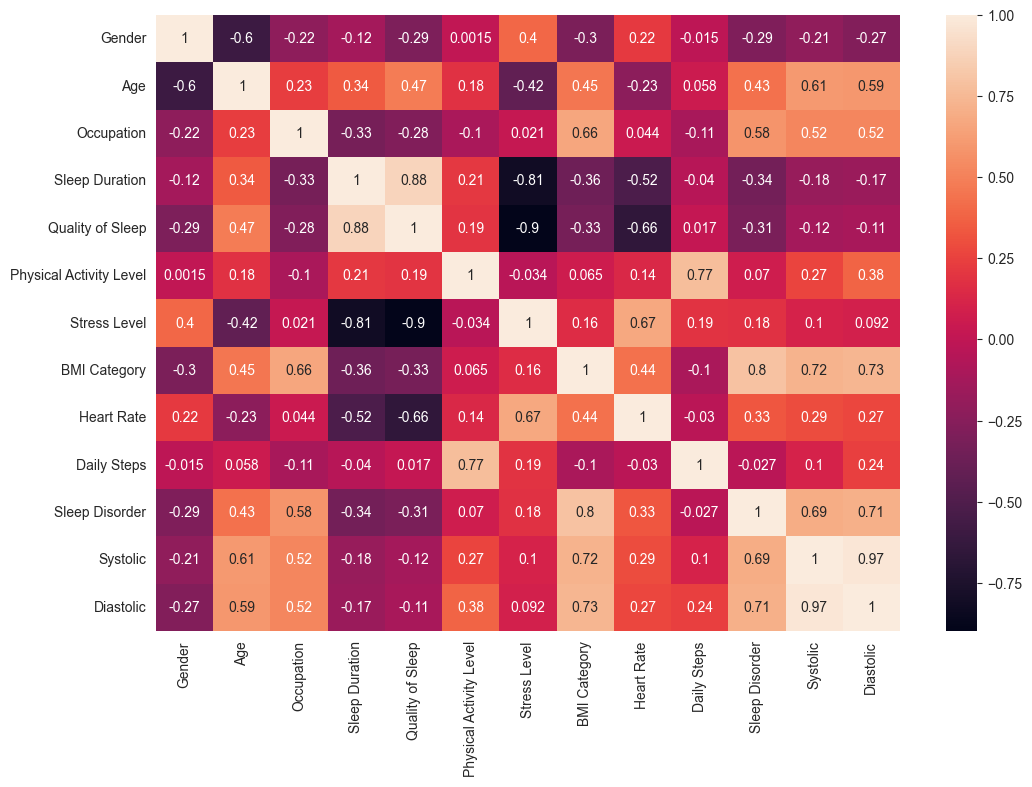

In [47]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True)

In [48]:
df.describe()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic,Diastolic
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,0.505348,42.184492,3.772727,7.132086,7.312834,59.171123,5.385027,0.927807,70.165775,6816.844920,0.414439,128.553476,84.649733
std,0.500641,8.673133,3.056081,0.795657,1.196956,20.830804,1.774526,1.010734,4.135676,1617.915679,0.493285,7.748118,6.161611
min,0.000000,27.000000,0.000000,5.800000,4.000000,30.000000,3.000000,0.000000,65.000000,3000.000000,0.000000,115.000000,75.000000
25%,0.000000,35.250000,1.000000,6.400000,6.000000,45.000000,4.000000,0.000000,68.000000,5600.000000,0.000000,125.000000,80.000000
50%,1.000000,43.000000,3.000000,7.200000,7.000000,60.000000,5.000000,0.000000,70.000000,7000.000000,0.000000,130.000000,85.000000
75%,1.000000,50.000000,5.000000,7.800000,8.000000,75.000000,7.000000,2.000000,72.000000,8000.000000,1.000000,135.000000,90.000000
max,1.000000,59.000000,10.000000,8.500000,9.000000,90.000000,8.000000,3.000000,86.000000,10000.000000,1.000000,142.000000,95.000000


<Axes: >

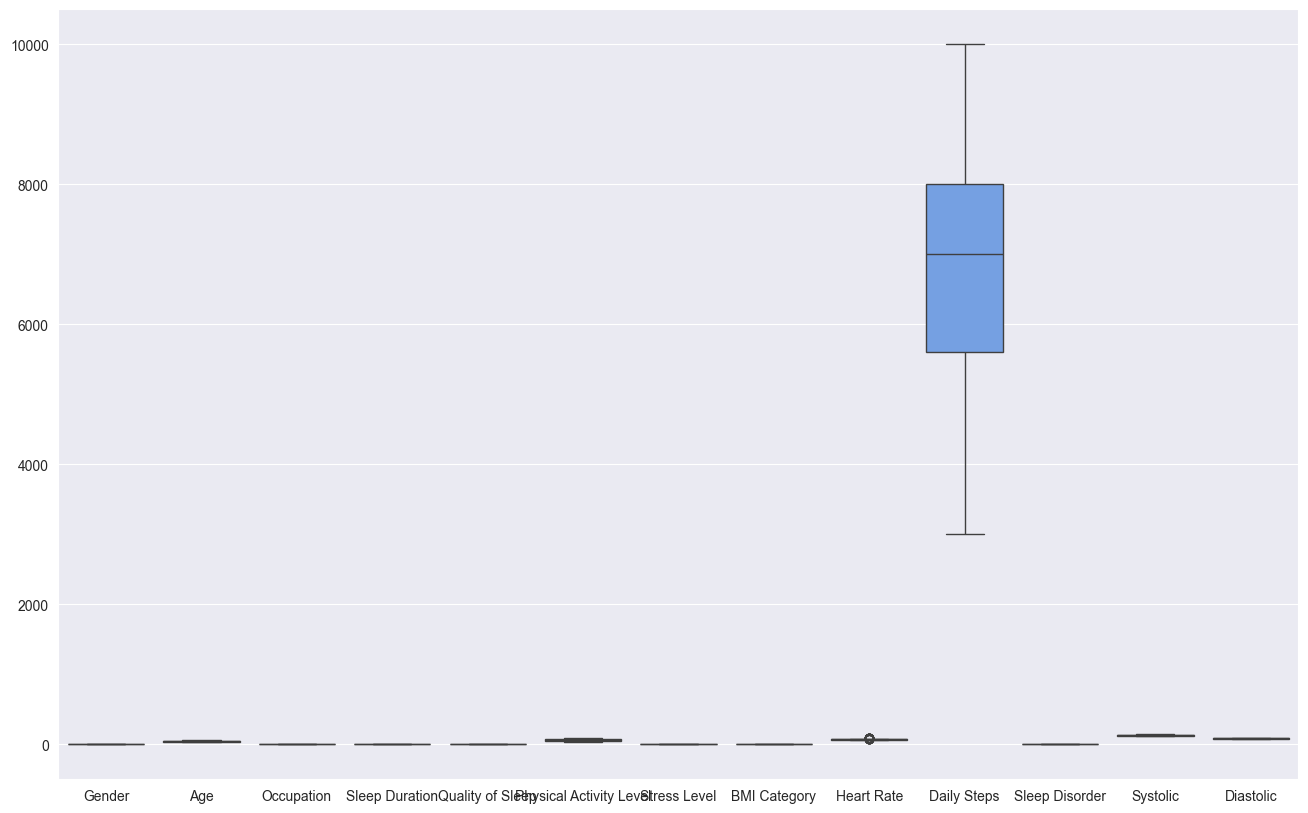

In [49]:
plt.figure(figsize=(16,10))
sns.boxplot(df)

In [50]:
import pandas as pd
import numpy as np

def drop_highly_correlated_features(df, target_col, threshold=0.8):

    # Sadece sayısal sütunları al
    corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr().abs()

    # Hedef sütunu hariç tut
    corr_matrix = corr_matrix.drop(index=target_col, columns=target_col)

    # Üst üçgen (upper triangle) matrisi oluştur
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Fazla korelasyonlu sütunları bul
    to_drop = [
        column for column in upper_tri.columns
        if any(upper_tri[column] > threshold)
    ]

    # Sütunları kaldır
    df_filtered = df.drop(columns=to_drop, errors='ignore')

    print("🔍 Fazla korelasyonlu sütunlar (>|{}|):".format(threshold))
    if to_drop:
        for c in to_drop:
            print("  -", c)
    else:
        print("  Hiçbiri (veri gayet temiz görünüyor!) ✅")

    print("\n✅ Kalan sütun sayısı:", df_filtered.shape[1])
    return df_filtered, to_drop


In [51]:
df_clean, dropped_cols = drop_highly_correlated_features(df, target_col='Quality of Sleep', threshold=0.85)

🔍 Fazla korelasyonlu sütunlar (>|0.85|):
  - Diastolic

✅ Kalan sütun sayısı: 12


In [52]:
df_clean

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic
0,1,27,9,6.1,6,42,6,2,77,4200,0,126.0
1,1,28,1,6.2,6,60,8,0,75,10000,0,125.0
2,1,28,1,6.2,6,60,8,0,75,10000,0,125.0
3,1,28,6,5.9,4,30,8,3,85,3000,1,140.0
4,1,28,6,5.9,4,30,8,3,85,3000,1,140.0
...,...,...,...,...,...,...,...,...,...,...,...,...
369,0,59,5,8.1,9,75,3,2,68,7000,1,140.0
370,0,59,5,8.0,9,75,3,2,68,7000,1,140.0
371,0,59,5,8.1,9,75,3,2,68,7000,1,140.0
372,0,59,5,8.1,9,75,3,2,68,7000,1,140.0


In [53]:
df_clean.drop(['Gender', 'Occupation', 'Daily Steps', 'Systolic'], axis=1, inplace=True)
df_clean.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Sleep Disorder
0,27,6.1,6,42,6,2,77,0
1,28,6.2,6,60,8,0,75,0
2,28,6.2,6,60,8,0,75,0
3,28,5.9,4,30,8,3,85,1
4,28,5.9,4,30,8,3,85,1


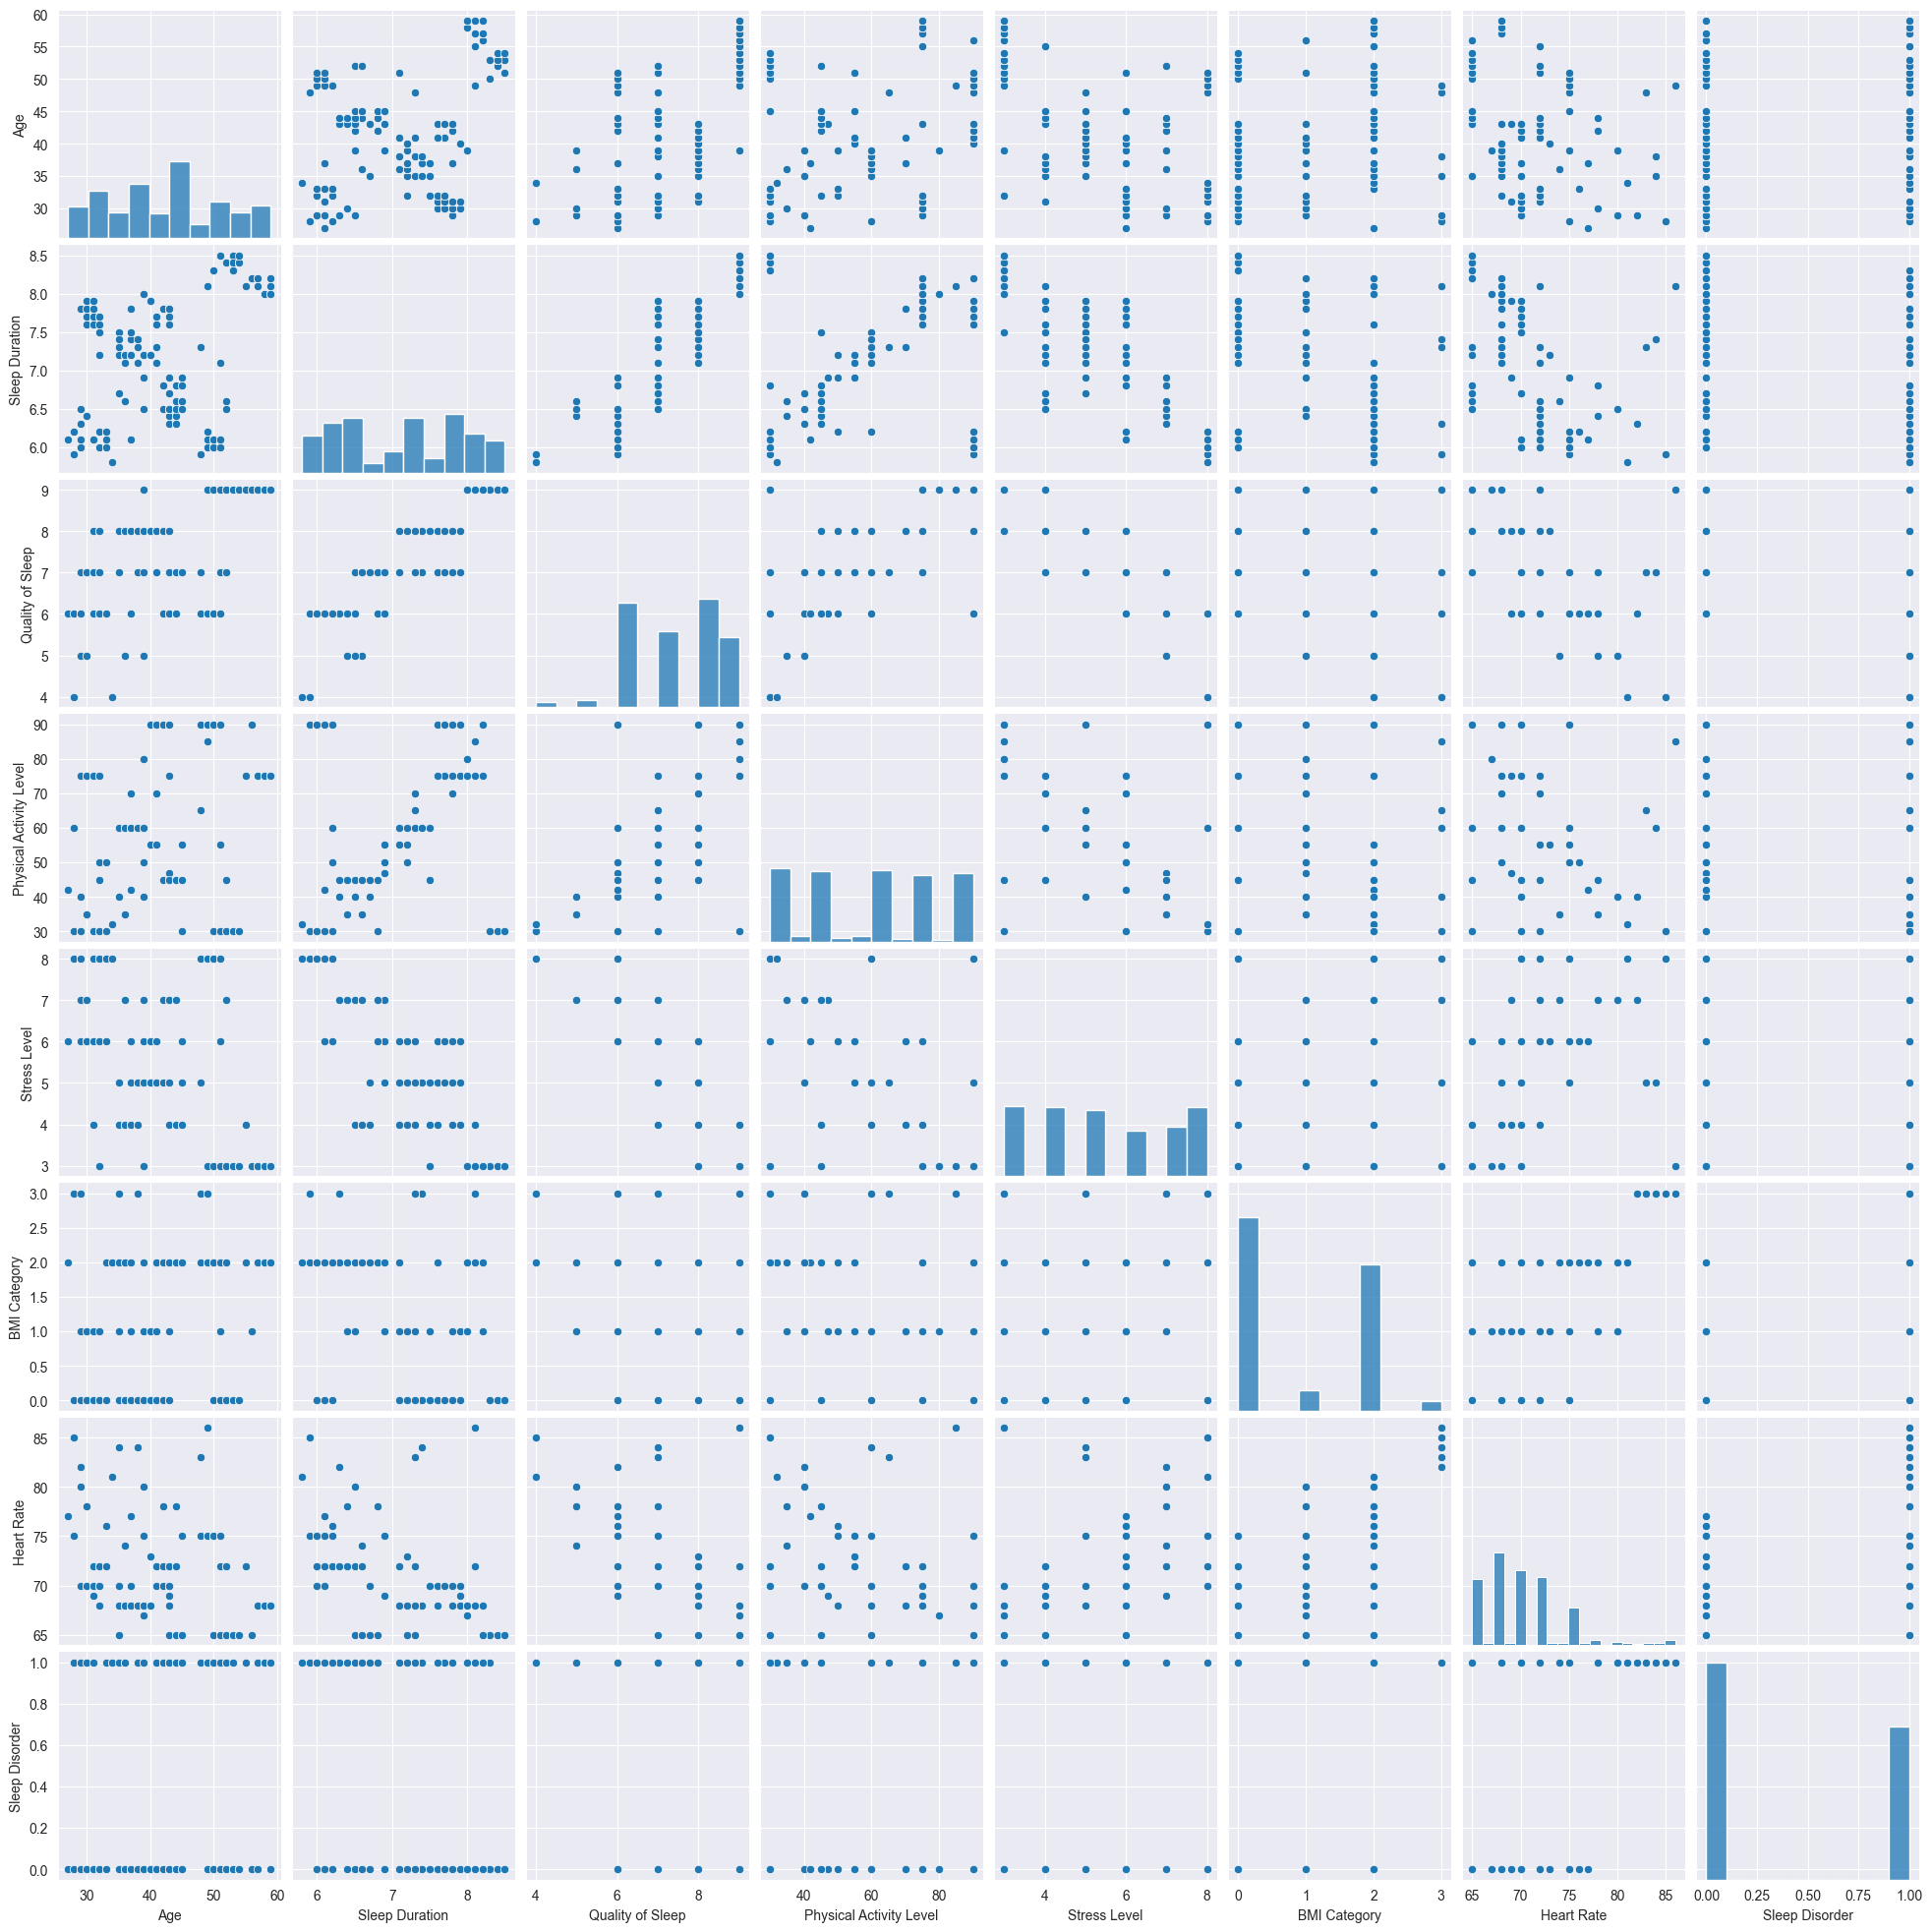

In [54]:
sns.pairplot(df_clean)
plt.show()

<Axes: >

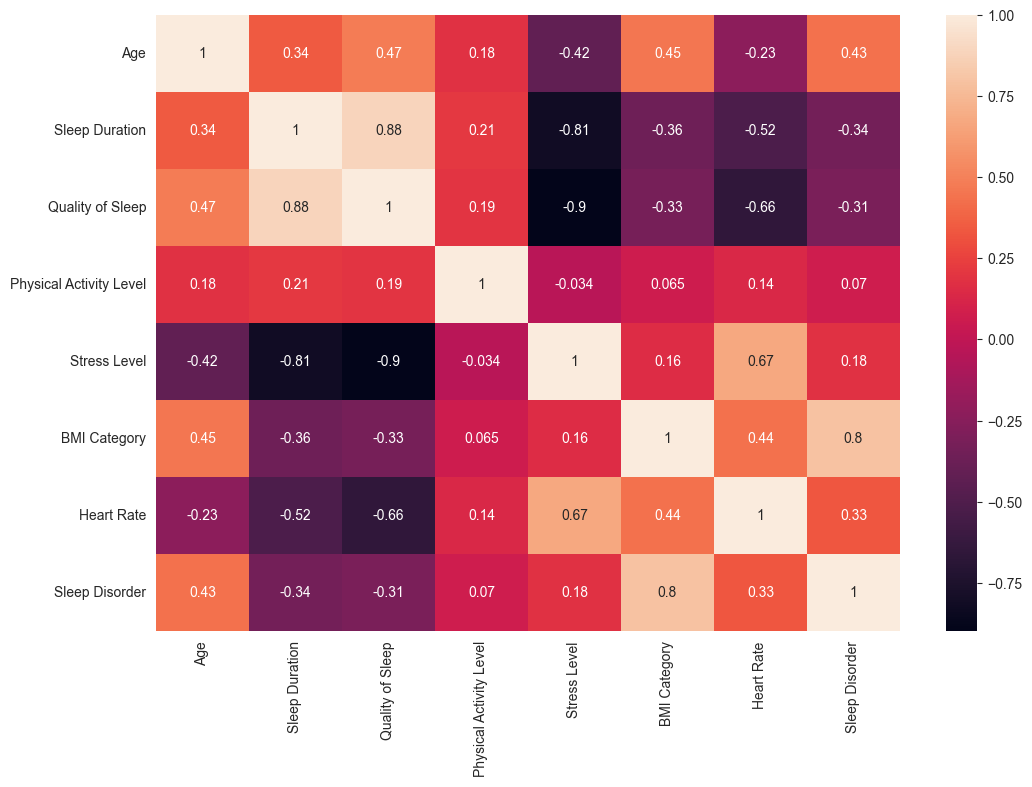

In [55]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clean.corr(), annot=True)

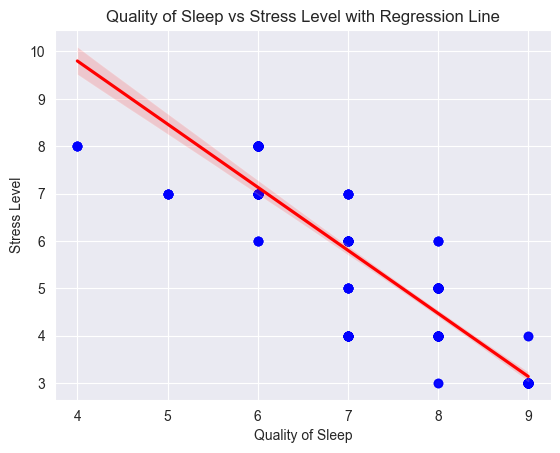

In [56]:
sns.regplot(x=df_clean['Quality of Sleep'], y=df_clean['Stress Level'], data=df_clean, scatter_kws={"color": "blue"}, line_kws={"color": "red"}) # scatter_kws for scatter plot color, line_kws for regression line color. It is try to draw how it can be the best fit line
plt.xlabel('Quality of Sleep')
plt.ylabel('Stress Level')
plt.title('Quality of Sleep vs Stress Level with Regression Line')
plt.show()

In [57]:
X = df_clean.drop('Quality of Sleep', axis=1)
y = df_clean['Quality of Sleep']

In [58]:
X

,Age,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Sleep Disorder
0,27,6.1,42,6,2,77,0
1,28,6.2,60,8,0,75,0
2,28,6.2,60,8,0,75,0
3,28,5.9,30,8,3,85,1
4,28,5.9,30,8,3,85,1
...,...,...,...,...,...,...,...
369,59,8.1,75,3,2,68,1
370,59,8.0,75,3,2,68,1
371,59,8.1,75,3,2,68,1
372,59,8.1,75,3,2,68,1


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
X_train

,Age,Sleep Duration,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Sleep Disorder
192,43,6.5,45,7,2,72,1
75,33,6.0,30,8,0,72,0
84,35,7.5,60,5,1,70,0
362,59,8.2,75,3,2,68,1
16,29,6.5,40,7,1,80,1
...,...,...,...,...,...,...,...
71,33,6.1,30,8,0,72,0
106,37,6.1,42,6,2,77,0
270,49,6.1,90,8,2,75,1
348,57,8.2,75,3,2,68,1


In [61]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [62]:
X_train

array([[ 0.05581074, -0.83345749, -0.72864422, ...,  1.07831106,
         0.48108094,  1.19619995],
       [-1.11114118, -1.4685334 , -1.45036889, ..., -0.93050518,
         0.48108094, -0.83598064],
       [-0.87775079,  0.43669434, -0.00691955, ...,  0.07390294,
        -0.01407638, -0.83598064],
       ...,
       [ 0.7559819 , -1.34151822,  1.43652979, ...,  1.07831106,
         1.22381692,  1.19619995],
       [ 1.68954343,  1.32580062,  0.71480512, ...,  1.07831106,
        -0.5092337 ,  1.19619995],
       [-0.7610556 ,  0.05564879, -0.00691955, ..., -0.93050518,
        -0.5092337 , -0.83598064]])

In [63]:
X_test

array([[ 1.22276266,  1.70684617, -1.45036889, -1.30893281, -0.93050518,
        -1.25196968, -0.83598064],
       [-1.34453156, -1.34151822, -1.45036889,  1.52298405, -0.93050518,
         0.48108094, -0.83598064],
       [-1.57792194, -1.4685334 , -1.45036889,  1.52298405, -0.93050518,
        -0.01407638, -0.83598064],
       [ 1.22276266,  1.70684617, -1.45036889, -1.30893281, -0.93050518,
        -1.25196968, -0.83598064],
       [-1.22783637, -1.4685334 , -1.45036889,  1.52298405, -0.93050518,
         0.48108094, -0.83598064],
       [ 0.17250594, -0.96047267, -0.72864422,  0.95660068,  1.07831106,
         0.48108094,  1.19619995],
       [-1.11114118, -1.4685334 , -1.45036889,  1.52298405, -0.93050518,
         0.48108094, -0.83598064],
       [-0.64436041,  0.05564879, -0.00691955, -0.74254944, -0.93050518,
        -0.5092337 , -0.83598064],
       [ 1.33945786,  1.57983099, -1.45036889, -1.30893281, -0.93050518,
        -1.25196968, -0.83598064],
       [-0.52766522,  0.1826

In [64]:
regression = LinearRegression()
regression.fit(X_train, y_train)

LinearRegression()

In [65]:
y_pred = regression.predict(X_test)
y_pred

array([9.2294723 , 5.73759472, 5.61980368, 9.2294723 , 5.7490925 ,
       6.04752577, 5.79025662, 7.99097631, 9.24097008, 7.6828942 ,
       6.01785944, 7.19863329, 7.69439198, 5.7490925 , 7.69439198,
       6.09930861, 5.84785721, 6.01785944, 9.24097008, 7.9498122 ,
       7.17563772, 8.17768877, 5.81992295, 7.19364212, 7.23480623,
       7.62356154, 6.01785944, 6.03602799, 6.03602799, 8.81971605,
       7.24646817, 7.94374362, 7.22829962, 8.87904871, 6.06964228,
       7.99097631, 5.80842516, 7.18713551, 7.69439198, 8.077192  ,
       6.29050974, 6.09930861, 5.71384825, 6.03602799, 7.67139641,
       7.99097631, 7.9296197 , 7.26946374, 4.52742714, 7.25796595,
       8.79672048, 6.69391266, 6.06964228, 8.00553525, 6.47797511,
       8.79672048, 6.57042032, 4.52742714, 8.77855194, 5.79025662,
       7.6828942 , 6.43617135, 5.79025662, 7.22829962, 7.22330845,
       5.81992295, 6.01785944, 9.2294723 , 8.18918656, 6.70205901,
       7.73649455, 6.03602799, 9.15864185, 6.09930861, 8.84938

In [66]:
mae = mean_absolute_error(y_test, y_pred) # y_test are the true values, y_pred are the predicted values
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2 ):", r2)

Mean Absolute Error (MAE): 0.20509438362228186
Mean Squared Error (MSE): 0.06252201877274052
Root Mean Squared Error (RMSE): 0.2500440336675533
R-squared (R2 ): 0.9585568753715926


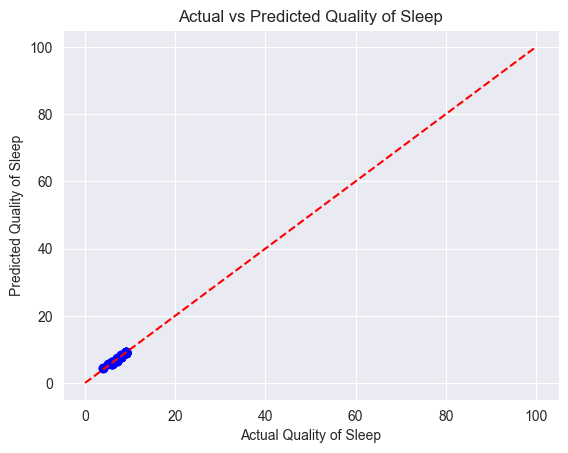

In [67]:
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel('Actual Quality of Sleep')
plt.ylabel('Predicted Quality of Sleep')
plt.title('Actual vs Predicted Quality of Sleep')
plt.plot([0, 100], [0, 100], color='red', linestyle='--') # diagonal line
plt.show()

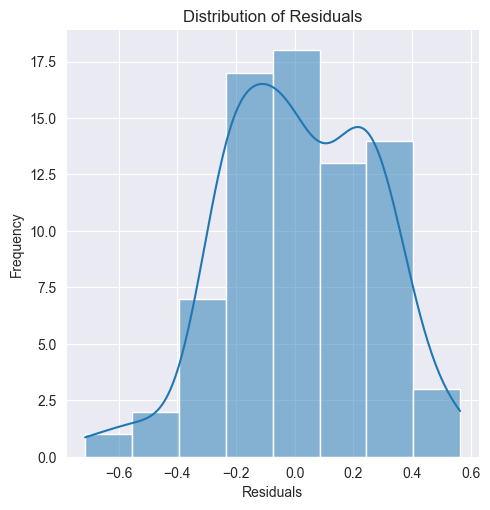

In [68]:
residuals = y_test - y_pred # residuals = actual - predicted
sns.displot(residuals, kde=True) # distribution of residuals kde=True to show the kernel density estimate
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [69]:
new_data = {
    'Age': [25],
    'Sleep Duration': [6.0],
    'Physical Activity Level': [70],
    'Stress Level': [8],
    'BMI Category': [2],  # örnek: Normal Weight
    'Heart Rate': [90],
    'Sleep Disorder': [0],  # örnek: Healthy
}

new_df = pd.DataFrame(new_data)
new_scaled = scaler.transform(new_df)
pred = regression.predict(new_scaled)

print("New Data Prediction:")
print("Quality of Sleep from 1 to 10")
print("-" * 35)
print(f"Predicted Quality of Sleep: {pred[0]:.2f}")
print("-" * 35)

New Data Prediction:
Quality of Sleep from 1 to 10
-----------------------------------
Predicted Quality of Sleep: 5.18
-----------------------------------


In [70]:
lasso = Lasso()
lasso.fit(X_train, y_train) # fit the model

Lasso()

In [71]:
# Ridge Regression Model
ridge = Ridge()
ridge.fit(X_train, y_train) # fit the model

Ridge()

In [72]:
# ElasticNet Regression Model
elastic = ElasticNet()
elastic.fit(X_train, y_train) # fit the model

ElasticNet()

In [73]:
print("All Models Performance Summary:")
models = {
    "Linear Regression": regression,
    "Lasso Regression": lasso,
    "Ridge Regression": ridge,
    "ElasticNet Regression": elastic
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name} Performance:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"R^2 Score: {r2:.4f}")

All Models Performance Summary:

Linear Regression Performance:
Mean Squared Error: 0.0625
Root Mean Squared Error: 0.2500
Mean Absolute Error: 0.2051
R^2 Score: 0.9586

Lasso Regression Performance:
Mean Squared Error: 1.4450
Root Mean Squared Error: 1.2021
Mean Absolute Error: 1.0398
R^2 Score: 0.0422

Ridge Regression Performance:
Mean Squared Error: 0.0628
Root Mean Squared Error: 0.2506
Mean Absolute Error: 0.2069
R^2 Score: 0.9584

ElasticNet Regression Performance:
Mean Squared Error: 0.6854
Root Mean Squared Error: 0.8279
Mean Absolute Error: 0.7131
R^2 Score: 0.5457


In [74]:
ridgecv = RidgeCV(cv=5) # cv=5 means 5 fold cross validation
ridgecv.fit(X_train, y_train)
y_pred = ridgecv.predict(X_test)

In [75]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [76]:
print("RidgeCV Regression Model Performance:")
print(f"Best Alpha: {ridgecv.alpha_:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

RidgeCV Regression Model Performance:
Best Alpha: 1.0000
Mean Absolute Error: 0.2069
Mean Squared Error: 0.0628
Root Mean Squared Error: 0.2506
R^2 Score: 0.9584


In [77]:
from sklearn.neural_network import MLPRegressor

# Modeli tanımla
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # iki katman: 64 ve 32 nöron
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=1000,
    random_state=42
)

# Eğit
mlp.fit(X_train, y_train)

# Tahmin et
y_pred = mlp.predict(X_test)

# Performans metrikleri
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 0.0957
Mean Squared Error (MSE): 0.0277
Root Mean Squared Error (RMSE): 0.1665
R-squared (R²): 0.9816


In [78]:
new_data = {
    'Age': [25],
    'Sleep Duration': [6.0],
    'Physical Activity Level': [70],
    'Stress Level': [8],
    'BMI Category': [2],  # örnek: Normal Weight
    'Heart Rate': [90],
    'Sleep Disorder': [0],  # örnek: Healthy
}

new_df = pd.DataFrame(new_data)
new_scaled = scaler.transform(new_df)
pred = mlp.predict(new_scaled)

print("New Data Prediction:")
print("Quality of Sleep from 1 to 10")
print("-" * 35)
print(f"Predicted Quality of Sleep: {pred[0]:.2f}")
print("-" * 35)

New Data Prediction:
Quality of Sleep from 1 to 10
-----------------------------------
Predicted Quality of Sleep: 6.98
-----------------------------------


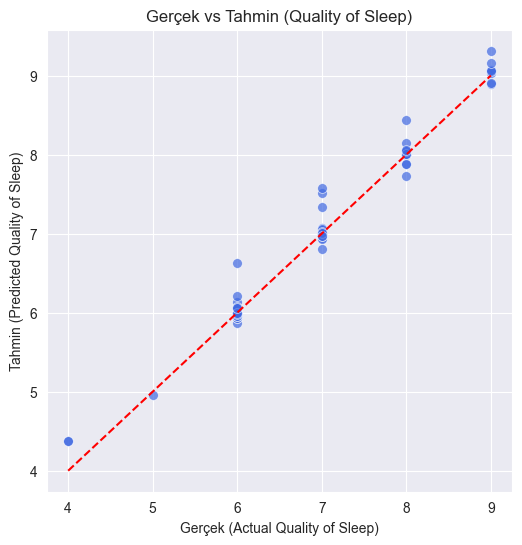

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color='royalblue', s=50, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal çizgi
plt.xlabel("Gerçek (Actual Quality of Sleep)")
plt.ylabel("Tahmin (Predicted Quality of Sleep)")
plt.title("Gerçek vs Tahmin (Quality of Sleep)")
plt.grid(True)
plt.show()

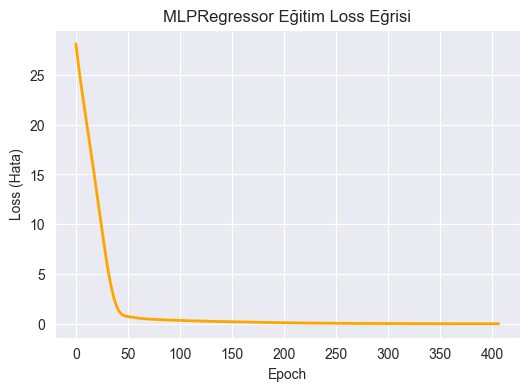

In [80]:
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_, color='orange', linewidth=2)
plt.title("MLPRegressor Eğitim Loss Eğrisi")
plt.xlabel("Epoch")
plt.ylabel("Loss (Hata)")
plt.grid(True)
plt.show()

In [81]:
from sklearn.metrics import mean_squared_error, r2_score

# Eğitim seti tahminleri
y_train_pred = mlp.predict(X_train)

train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = mean_squared_error(y_test, y_pred, squared=False)
test_r2 = r2_score(y_test, y_pred)

print(f"Train RMSE: {train_rmse:.4f} | Train R²: {train_r2:.4f}")
print(f"Test RMSE : {test_rmse:.4f} | Test R² : {test_r2:.4f}")

Train RMSE: 0.1659 | Train R²: 0.9803
Test RMSE : 0.1665 | Test R² : 0.9816


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


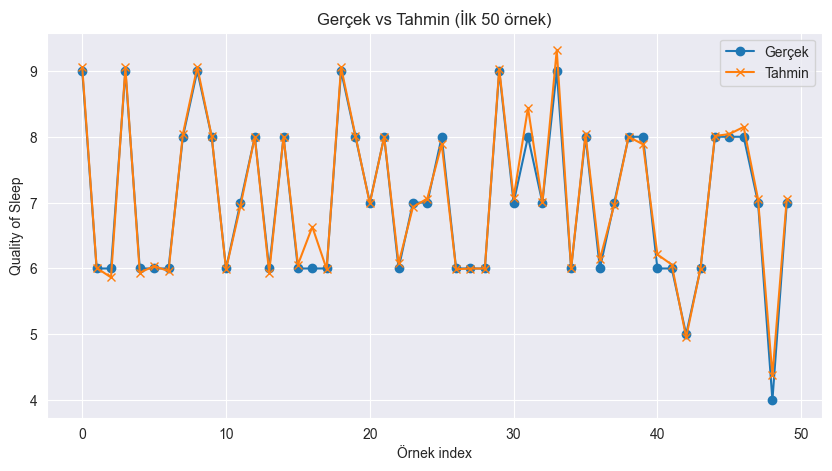

In [82]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label='Gerçek', marker='o')
plt.plot(y_pred[:50], label='Tahmin', marker='x')
plt.title("Gerçek vs Tahmin (İlk 50 örnek)")
plt.xlabel("Örnek index")
plt.ylabel("Quality of Sleep")
plt.legend()
plt.grid(True)
plt.show()